Text mining: Implement a text mining model to analyze customer reviews and identify sentiments
(positive, negative, neutral) and preferences using techniques like sentiment analysis and keyword
extraction.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C:/Users/PRANAV/Downloads/imdb/IMDB Dataset.csv").head(1000)

In [3]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
995,Nothing is sacred. Just ask Ernie Fosselius. T...,positive
996,I hated it. I hate self-aware pretentious inan...,negative
997,I usually try to be professional and construct...,negative
998,If you like me is going to see this in a film ...,negative


## Preprocess

In [4]:
import re

In [5]:
def clean(text):
    text = re.sub("<.*?>", "", text)
    text = re.sub("[^a-zA-Z ]", "", text)
    return text.lower()

In [6]:
df["clean"] = df["review"].apply(clean)

## Sentiment

In [8]:
!pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 1.8 MB/s eta 0:00:00


In [9]:
from textblob import TextBlob

In [10]:
def sentiment(text):
    p = TextBlob(text).sentiment.polarity
    if p > 0:
        return "Positive"
    elif p < 0:
        return "Negative"
    else:
        return "Neutral"

In [11]:
df["sentiment"] = df["clean"].apply(sentiment)

## KEYWORDS

In [13]:
!pip install rake-nltk

In [14]:
from rake_nltk import Rake

In [15]:
r = Rake()

In [16]:
def get_keywords(text):
    r.extract_keywords_from_text(text)
    return r.get_ranked_phrases()[:3]

In [17]:
df["keywords"] = df["clean"].apply(get_keywords)

In [22]:
df[["review", "keywords"]]

,review,keywords
0,One of the other reviewers has mentioned that ...,[mainstream audiences forget charm forget roma...
1,A wonderful little production. <br /><br />The...,"[traditional dream techniques remains solid, h..."
2,I thought this was a wonderful way to spend ti...,"[well bread suspected serial killer, match poi..."
3,Basically there's a family where a little boy ...,"[well playing parents descent dialogs, little ..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",[mr matteis direction steve buscemi rosario da...
...,...,...
995,Nothing is sacred. Just ask Ernie Fosselius. T...,"[make sure filmmakers dont get, god gave us ha..."
996,I hated it. I hate self-aware pretentious inan...,"[sophomoric claptrap tinting drivel, hate self..."
997,I usually try to be professional and construct...,[ever seen bad acting bad effects bad script b...
998,If you like me is going to see this in a film ...,[slow paced confusing boring poorly constructe...


## Wordcloud

In [24]:
!pip install wordcloud

In [25]:
from wordcloud import WordCloud

In [26]:
import matplotlib.pyplot as plt

In [27]:
text = " ".join(df["clean"])
wc = WordCloud(background_color="white").generate(text)

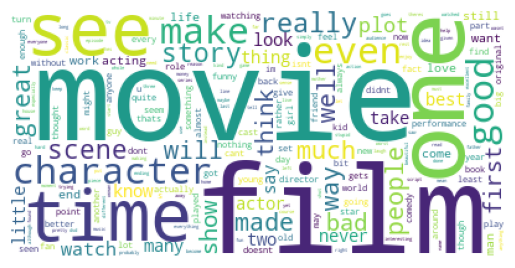

In [28]:
plt.imshow(wc)
plt.axis("off")
plt.show()

In [29]:
df[["review","sentiment","keywords"]]

,review,sentiment,keywords
0,One of the other reviewers has mentioned that ...,Positive,[mainstream audiences forget charm forget roma...
1,A wonderful little production. <br /><br />The...,Positive,"[traditional dream techniques remains solid, h..."
2,I thought this was a wonderful way to spend ti...,Positive,"[well bread suspected serial killer, match poi..."
3,Basically there's a family where a little boy ...,Negative,"[well playing parents descent dialogs, little ..."
4,"Petter Mattei's ""Love in the Time of Money"" is...",Positive,[mr matteis direction steve buscemi rosario da...
...,...,...,...
995,Nothing is sacred. Just ask Ernie Fosselius. T...,Positive,"[make sure filmmakers dont get, god gave us ha..."
996,I hated it. I hate self-aware pretentious inan...,Negative,"[sophomoric claptrap tinting drivel, hate self..."
997,I usually try to be professional and construct...,Negative,[ever seen bad acting bad effects bad script b...
998,If you like me is going to see this in a film ...,Negative,[slow paced confusing boring poorly constructe...
